# STL Decomposition using LOESS
(Locally estimated scatterplot smoothning)

- This method is Robust to outliers. It's useful when you have outliers in your timeseries data.
- Seasonality is modeled flexibily using LOESS smoothing and not as fixed pattern. Unlike Classic Decomposition, in STL Decomposition the Seasonal part is not just shown as repetative cyclic patterns.
- This method is useful for real work data.
- It can only handle additive Time Series data, not good with Multiplicative models.

In [1]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from helpers import *

In [2]:
stock_data = get_stock_data()
    
stock_data.info()

Loading Data From Local
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 499 entries, 2024-01-02 to 2025-12-26
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   499 non-null    float64
 1   (High, AAPL)    499 non-null    float64
 2   (Low, AAPL)     499 non-null    float64
 3   (Open, AAPL)    499 non-null    float64
 4   (Volume, AAPL)  499 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.4 KB


In [ ]:
# It only supports Additive model so no need to model param like classical
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

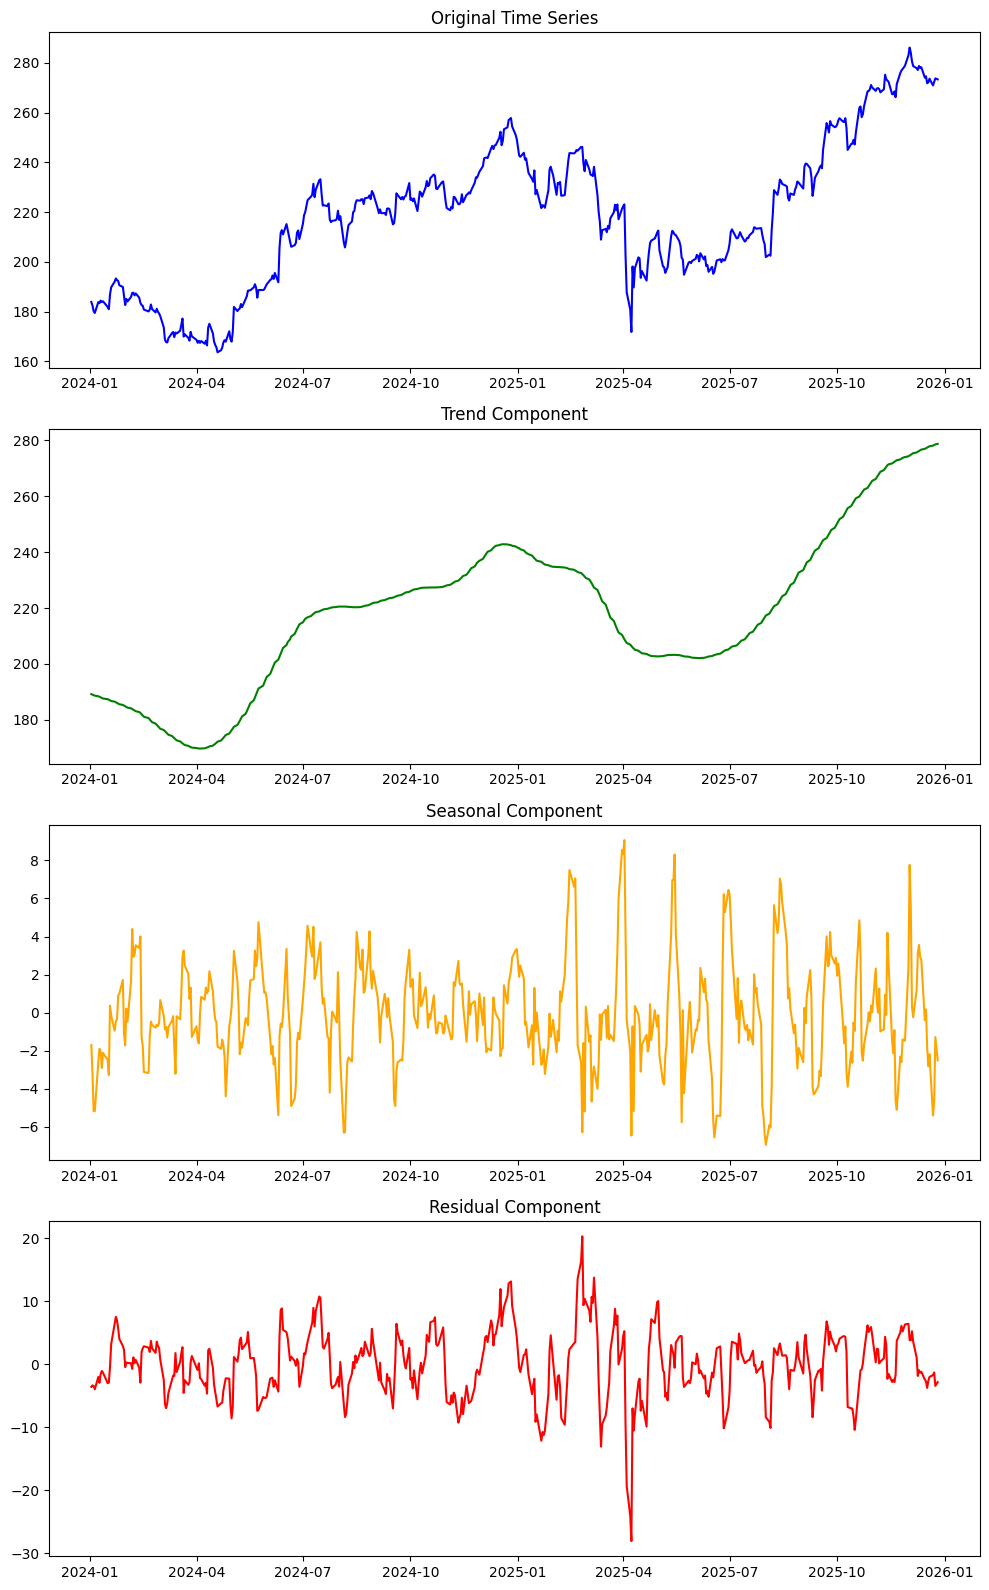

In [6]:
fig, axs = plt.subplots(4, 1, figsize=(10, 16))

# Actual
axs[0].plot(result.observed, label='Original', color='blue')
axs[0].set_title("Original Time Series")
# Trend
axs[1].plot(result.trend, label='Trend', color='green')
axs[1].set_title("Trend Component")
# Seasonal
axs[2].plot(result.seasonal, label='Seasonal', color='orange')
axs[2].set_title("Seasonal Component")
# Residual
axs[3].plot(result.resid, label='Residual', color='red')
axs[3].set_title("Residual Component")

fig.tight_layout()
plt.show()